
## Minimum Norm Solution






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

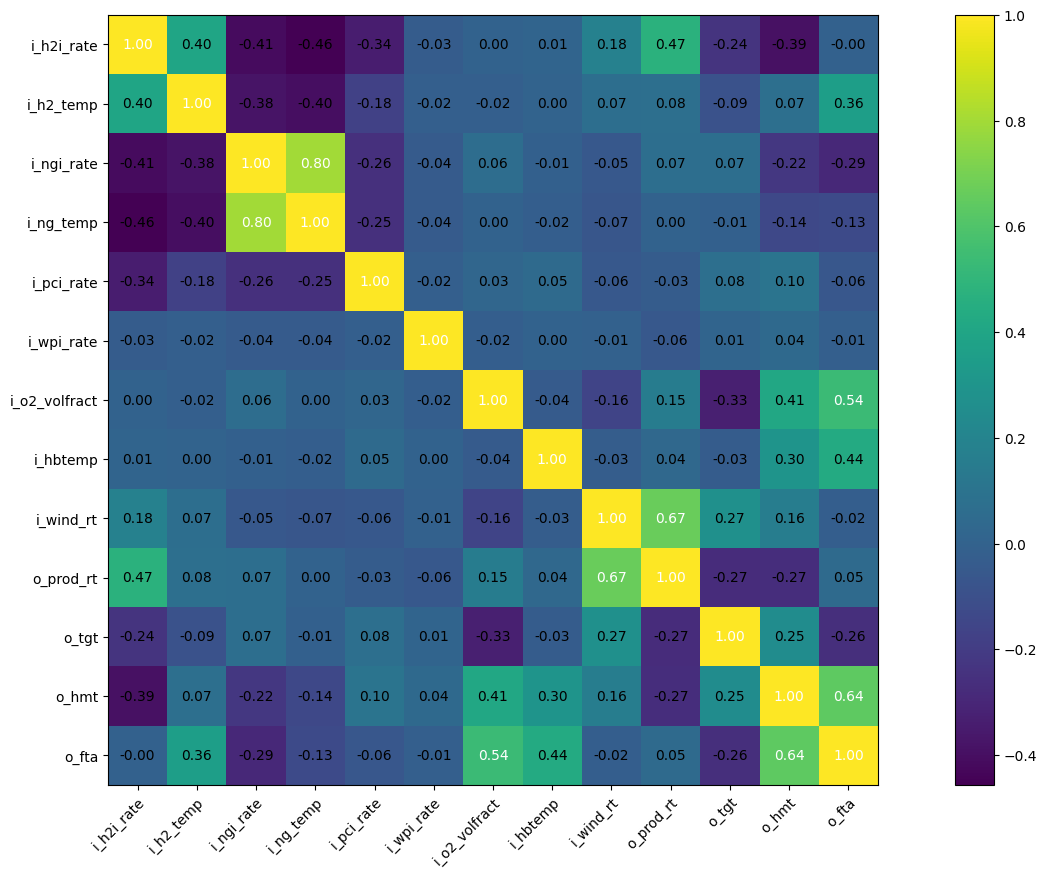

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
4


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 4)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 4)
(1000, 4)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 4)
(1000, 4)


In [17]:

from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca





In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 4)
(1000, 4)
(3999, 4)
(1000, 4)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 4     ## 7
n_outputs = 4




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 4     ## 7
n_outputs = 4





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.9570773839950562
100 ..... 0.9182881116867065
200 ..... 0.6806426644325256
300 ..... 0.6155630350112915
400 ..... 0.9922534823417664
500 ..... 0.6805620193481445
600 ..... 0.7460992932319641
700 ..... 0.6004413366317749
800 ..... 0.6913589239120483
900 ..... 0.8545182943344116


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.8737, 1298.0046, 8415.6816, 2305.8806]])
y_deviations: tensor([[  50.3507,  521.2630, 1504.3140,  208.7552]])
x_means: tensor([[     0.0000,      0.0000,      0.0000,     -0.0000]])
x_deviations: tensor([[271.7256, 157.1472,  51.2281,  36.2675]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.5230,  776.7416, 6911.3677, 2097.1255]])
tensor([[ 148.2244, 1819.2676, 9919.9961, 2514.6357]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[-271.7256, -157.1472,  -51.2281,  -36.2675]])
tensor([[271.7256, 157.1472,  51.2281,  36.2675]])



## Is model  invertible ?

* use the Jacobian


In [29]:

import torch
from torch.autograd.functional import jacobian


In [30]:

## x = torch.randn(1, 7, requires_grad=True)

x = torch.randn(      7, requires_grad=True)  # shape [7]

x = torch.randn(      4, requires_grad=True)  # shape [7]


In [31]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  # Only return 1 tensor to get a clean Jacobian




In [32]:

## J = jacobian(model_Forward, x)

J = jacobian(wrapped_model, x)


In [33]:

print( len(J) )


1


In [34]:


print( J.shape )  # Should be [1, 4, 7]


torch.Size([1, 4, 4])


In [35]:

u, s, v = torch.svd(J)  


In [36]:

rank = (s > 1e-5).sum()


In [37]:


print("Local Jacobian rank:", rank.item())


Local Jacobian rank: 4



## Example of Min Norm Solution



## Approach


In [38]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)


In [39]:


def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x







In [40]:



x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')



torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  20.83656899    4.78303433   15.22902382   25.39831782  628.28835184
 1473.70721014  201.31931134]
real
[   0.           80.16850155  120.17961101   26.26316086  300.10938681
 1480.13358978  186.00221415]
1
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.05147539    5.84639801   68.79110627   25.55596244  536.91047831
 1631.5812227   195.93110483]
real
[   2.87756824  122.37988783    0.           25.63769034  299.94373852
 1599.85150571  192.9935269 ]
2
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1,

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  23.6764994     4.0653829     0.03689205   25.34338392  649.96568657
 1437.64679957  202.85225725]
real
[  23.27006579    0.            0.           25.21016483  300.19159956
 1448.11162666  204.13626732]
44
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  25.38966264    5.16978998    0.           25.35963501  753.88567024
 1399.06782472  203.46591368]
real
[  24.69741165    0.            0.           25.16801364  600.2136994
 1600.24086752  202.71678248]
45
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  25.91570512    5.08800076    0.           25.25780528  651.67089007
 1453.60741668  203.89048443]
real
[  26.95562231    4.58008604    4.92575322   25.33934018 1199.99324004
 1600.13630198  201.20989526]
64
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  19.81579727    4.8723452    21.49571989   25.4403546   644.05041971
 1470.74217189  200.74978513]
real
[   7.25595491    0.           79.7166424    25.92073705  300.02064961
 1200.0188766   197.37428826]
65
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  25.61257627    4.19890205    0.           25.31375605  675.1688409
 1407.80081143  203.87939612]
real
[  24.50790613    0.            0.           25.4864068   600.18370938
 1200.11072675  204.76742966]
116
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  26.16286597    5.07112554    0.           25.21596166  598.92133501
 1468.90894249  204.16617995]
real
[   9.05636872    1.66496938   71.79611113   25.66833836  299.9409142
 1447.97756452  196.95436961]
117
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  23.29277967    3.89036967    0.12568381   25.28795978  572.20612739
 1483.80222809  202.75412195]
real
[   6.0595928     0.           96.16056824   25.65344957  299.99300792
 1599.87245697  194.62625982]
137
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  19.94159299    4.3494571    19.08413997   25.37665199  571.24865486
 1509.23318534  200.92841104]
real
[   0.           29.03356654  118.96481573   26.03177746  300.02121302
 1479.98905732  190.35485126]
138
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfra

...

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  13.15513097    4.30717809   63.28648579   25.54677171  667.82193835
 1627.2016378   196.44007315]
real
[  14.87967614    0.           40.91785726   25.45554574  299.86894332
 1479.84013695  199.72688778]
845
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  19.75289716    3.38852626   21.66560883   25.3992767   591.21849655
 1499.8652269   200.79533269]
real
[  23.51871706    0.            0.           25.39665269  300.15748798
 1199.98039357  205.59324005]
846
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  20.39044837    5.95532612   11.75290859   25.32449684  485.88500733
 1509.82716309  201.52854336]
real
[   3.60291789    3.37945504  103.63472264   25.7267275   300.00846422
 1600.11587241  193.38205892]
865
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  12.29252007   12.83071832   53.87974159   25.54843971  525.47514489
 1574.32553008  196.91437366]
real
[   6.7202289     1.25392558   81.34418702   25.93675085  299.95520587
 1199.99297391  197.10369359]
866
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hb

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  19.31343453    4.32472598   24.80779374   25.45420348  641.73528912
 1473.42611746  200.49185955]
real
[  23.5284138     0.            0.           25.39635527  300.15625978
 1199.98558426  205.59812258]
918
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  16.48498263    4.83430445   39.31820931   25.46312489  582.52750244
 1548.52515237  198.92107599]
real
[  12.64413359    0.           57.58500093   25.43760231  299.95015621
 1599.8713388   197.95358634]
919
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfra

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  13.93735779    5.33121497   51.90079687   25.50829201  536.32004451
 1571.96765398  197.71183242]
real
[   2.53548377  122.36244032    0.           25.74170867  299.94650529
 1479.85442228  193.46414513]
939
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  20.21595877    4.31637983   19.53851469   25.40102101  627.75361713
 1496.6337108   200.88520369]
real
[  29.62048315    0.            0.           25.35362062 1200.04410633
 1479.92951118  203.20263259]
940
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  24.39810606    4.47294494    0.           25.25690066  534.99673894
 1456.65468307  203.62239747]
real
[  15.7020639     0.           37.95722484   25.43040061  300.10324036
 1480.05843042  200.14062607]
991
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  26.66789439    5.34122486    0.           25.31001787  718.31877262
 1390.00958644  204.31739039]
real
[  27.16865767    2.99905951    3.21456095   25.4267498  1200.0589789
 1480.17553324  201.96087329]
992
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbt

In [41]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 353.28198



## Now add Costs


In [42]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_latent = pca.components_ @ price_real

price_latent = torch.tensor(price_latent, dtype=torch.float32)


In [43]:

def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    ##delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01
    
    lambda_cost = 0.01
    
    ##################################
       
    ## delta_x = (J_pinv @ delta_y) - lambda_cost * price_latent
    ## delta_x = 0.01 * delta_x
    
    
    rhs     = J.T @ delta_y - lambda_cost * price_latent
    delta_x = torch.linalg.solve(J.T @ J, rhs)
    delta_x = 0.01 * delta_x
    
   
    #################################

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x






In [44]:


x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        # ---- compute cost at this iteration ----
        x_temp_np = x_temp.detach().numpy()
        x_temp_real = pca.inverse_transform(x_temp_np)

        # enforce physical constraint
        x_temp_real = np.maximum(x_temp_real, 0.0)

        cost = np.dot(price_real, x_temp_real)
        
        x_real_np         = x_real.detach().numpy()
        x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
        cost_real         = np.dot(price_real, x_real_np_sol)
       
        print(f"iteration {j} cost: {cost}...H2, PCI, NGI:", x_temp_real[:3] )
        print("real cost       :", cost_real)
        cost_diff    = cost - cost_real
        percent_diff = (cost - cost_real) / cost_real
        
    percent_diffs.append( percent_diff  )
          
    cost_diffs.append(       cost_diff  )
        
        
        
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')




torch.Size([1, 4, 4])
iteration 0 cost: 97.22863953094078...H2, PCI, NGI: [22.17045088  5.30867761  6.47631676]
real cost       : 91.28601856919279
torch.Size([1, 4, 4])
iteration 1 cost: 97.39005204116881...H2, PCI, NGI: [22.22541802  5.19768311  6.58139369]
real cost       : 91.28601856919279
torch.Size([1, 4, 4])
iteration 2 cost: 97.2784614012337...H2, PCI, NGI: [22.09725017  5.06080064  7.65732015]
real cost       : 91.28601856919279
torch.Size([1, 4, 4])
iteration 3 cost: 97.6144230099152...H2, PCI, NGI: [22.26628387  4.99322305  7.11212895]
real cost       : 91.28601856919279
torch.Size([1, 4, 4])
iteration 4 cost: 97.67262633841928...H2, PCI, NGI: [22.26007884  4.86838595  7.52785003]
real cost       : 91.28601856919279
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  22.26007884    4.86838595    7.52785003   25.37931054  650.04016175
 1449.92338576  202.07016818]
real
[   0.           80.16850155  120.17961101   26

iteration 4 cost: 113.7819863482817...H2, PCI, NGI: [27.23940021  4.82438553  0.        ]
real cost       : 88.0813890907891
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  27.23940021    4.82438553    0.           25.24556405  658.97949373
 1417.93842651  204.71846175]
real
[  21.65319162    0.95577633    1.02569253   25.25850367  299.99650392
 1448.02870596  203.31960117]
41
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 94.32247599014944...H2, PCI, NGI: [19.94285457  5.51107192 18.07997157]
real cost       : 75.91625995835291
torch.Size([1, 4, 4])
iteration 1 cost: 91.35477173850154...H2, PCI, NGI: [17.54336816  5.54113685 31.28032446]
real cost       : 75.91625995835291
torch.Size([1, 4, 4])
iteration 2 cost: 87.78307333401955...H2, PCI, NGI: [14.56101028  5.84476318 47.38853806]
real cost       : 75.91625995835291
torch.Size([1, 4, 4])
iteration 3 cost: 85.26616629953199...H2, PCI, NGI: [12.2

torch.Size([1, 4, 4])
iteration 1 cost: 94.16541398937154...H2, PCI, NGI: [20.04446354  5.53890599 16.89730765]
real cost       : 75.91625995835291
torch.Size([1, 4, 4])
iteration 2 cost: 92.7484998438354...H2, PCI, NGI: [19.04100731  5.58283852 22.0032642 ]
real cost       : 75.91625995835291
torch.Size([1, 4, 4])
iteration 3 cost: 91.17641727964684...H2, PCI, NGI: [17.90032138  5.69790061 27.7544623 ]
real cost       : 75.91625995835291
torch.Size([1, 4, 4])
iteration 4 cost: 89.10257429838799...H2, PCI, NGI: [16.29535503  6.05428887 35.73373061]
real cost       : 75.91625995835291
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  16.29535503    6.05428887   35.73373061   25.39220008  474.41347084
 1588.49437513  199.08791022]
real
[  11.75177666    0.           59.24206036   25.55808063  299.88932177
 1479.84054368  198.14628553]
50
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 100.1652605160220

torch.Size([1, 4, 4])
iteration 4 cost: 128.07120056865662...H2, PCI, NGI: [30.59165599  5.70457659  0.        ]
real cost       : 81.97138954370294
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  30.59165599    5.70457659    0.           25.1355526   654.53936246
 1415.46797832  206.44514499]
real
[  13.30081176    5.37641726   46.78345048   25.40879153  299.94706896
 1600.10654999  198.28266333]
62
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 95.65049816031548...H2, PCI, NGI: [20.88935935  5.46341052 13.25930051]
real cost       : 94.52002216800751
torch.Size([1, 4, 4])
iteration 1 cost: 94.68381868535909...H2, PCI, NGI: [19.87985044  5.56761452 19.19360483]
real cost       : 94.52002216800751
torch.Size([1, 4, 4])
iteration 2 cost: 92.99273497355595...H2, PCI, NGI: [18.38328379  5.64576055 27.62767849]
real cost       : 94.52002216800751
torch.Size([1, 4, 4])
iteration 3 cost: 90.643688464095

torch.Size([1, 4, 4])
iteration 0 cost: 94.60027328394439...H2, PCI, NGI: [20.08742907  5.51222006 17.47667388]
real cost       : 112.34264582754393
torch.Size([1, 4, 4])
iteration 1 cost: 92.32319497819498...H2, PCI, NGI: [18.14914168  5.65368822 28.14588008]
real cost       : 112.34264582754393
torch.Size([1, 4, 4])
iteration 2 cost: 89.82345314965738...H2, PCI, NGI: [15.93320718  5.97951756 40.22221373]
real cost       : 112.34264582754393
torch.Size([1, 4, 4])
iteration 3 cost: 85.48732823946858...H2, PCI, NGI: [12.12849243  6.72376643 60.49918416]
real cost       : 112.34264582754393
torch.Size([1, 4, 4])
iteration 4 cost: 84.62288789926231...H2, PCI, NGI: [11.02849559  7.23430232 66.54920643]
real cost       : 112.34264582754393
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.02849559    7.23430232   66.54920643   25.54240359  508.33340614
 1632.99226383  196.03779511]
real
[  10.93431618   69.09258197    0.      

...

torch.Size([1, 4, 4])
iteration 0 cost: 101.28545712559374...H2, PCI, NGI: [24.07435577  4.98803404  0.        ]
real cost       : 73.44705516033156
torch.Size([1, 4, 4])
iteration 1 cost: 112.18120054979532...H2, PCI, NGI: [27.05837863  3.94768603  0.        ]
real cost       : 73.44705516033156
torch.Size([1, 4, 4])
iteration 2 cost: 113.30093409625397...H2, PCI, NGI: [27.36543653  3.83918799  0.        ]
real cost       : 73.44705516033156
torch.Size([1, 4, 4])
iteration 3 cost: 114.90090181056155...H2, PCI, NGI: [27.7792443  3.7839246  0.       ]
real cost       : 73.44705516033156
torch.Size([1, 4, 4])
iteration 4 cost: 114.6994823715554...H2, PCI, NGI: [27.7472225   3.71059235  0.        ]
real cost       : 73.44705516033156
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  27.7472225     3.71059235    0.           25.25008562  673.07896333
 1399.66153519  205.0110766 ]
real
[  10.02654096    0.           68.84047354  

torch.Size([1, 4, 4])
iteration 0 cost: 94.67510264039919...H2, PCI, NGI: [19.95253373  5.84260398 18.0447275 ]
real cost       : 76.98074614209118
torch.Size([1, 4, 4])
iteration 1 cost: 91.41410201357924...H2, PCI, NGI: [17.15223102  6.25787838 33.09459914]
real cost       : 76.98074614209118
torch.Size([1, 4, 4])
iteration 2 cost: 86.30708448986545...H2, PCI, NGI: [12.70570062  7.25265242 56.46325918]
real cost       : 76.98074614209118
torch.Size([1, 4, 4])
iteration 3 cost: 84.41223714276762...H2, PCI, NGI: [10.5140724   8.47140802 67.76907903]
real cost       : 76.98074614209118
torch.Size([1, 4, 4])
iteration 4 cost: 82.23611812655162...H2, PCI, NGI: [ 7.48572315 11.13924468 82.30796169]
real cost       : 76.98074614209118
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   7.48572315   11.13924468   82.30796169   25.58951584  464.64041338
 1693.0060809   194.11777449]
real
[  13.12100388    2.59829849   43.79686429   

torch.Size([1, 4, 4])
iteration 2 cost: 95.63317460230492...H2, PCI, NGI: [22.00070244  5.07203787  5.11665398]
real cost       : 119.4991357125373
torch.Size([1, 4, 4])
iteration 3 cost: 95.97159695139354...H2, PCI, NGI: [22.51420325  4.90211608  2.02533573]
real cost       : 119.4991357125373
torch.Size([1, 4, 4])
iteration 4 cost: 95.40531147979702...H2, PCI, NGI: [22.41184639  4.73186794  2.05211597]
real cost       : 119.4991357125373
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  22.41184639    4.73186794    2.05211597   25.28068712  508.37891507
 1494.92081779  202.53091232]
real
[   6.91487187   91.19558302    1.28813043   25.6284594   299.95373249
 1479.98139779  195.68269333]
946
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 97.88150243059688...H2, PCI, NGI: [22.94346251  5.22809981  1.75910515]
real cost       : 73.44589270435523
torch.Size([1, 4, 4])
iteration 1 cost: 101.28928853229

iteration 3 cost: 103.62573291151975...H2, PCI, NGI: [24.82777536  4.31463149  0.        ]
real cost       : 70.65294159190731
torch.Size([1, 4, 4])
iteration 4 cost: 124.63815932933409...H2, PCI, NGI: [30.05714636  4.40957388  0.        ]
real cost       : 70.65294159190731
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  30.05714636    4.40957388    0.           25.13451141  669.19840669
 1448.79897843  205.93184797]
real
[   8.23902914    0.           84.89721621   25.58354833  300.04803832
 1599.89678246  195.72746518]
981
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 97.67501420993396...H2, PCI, NGI: [22.77127355  5.41415667  2.35152669]
real cost       : 110.06142620974623
torch.Size([1, 4, 4])
iteration 1 cost: 98.58551183236808...H2, PCI, NGI: [23.34441527  5.20785074  0.        ]
real cost       : 110.06142620974623
torch.Size([1, 4, 4])
iteration 2 cost: 101.617258591799...H2, PCI, NGI: 

iteration 3 cost: 94.5499180501148...H2, PCI, NGI: [20.05614452  4.59190454 19.46687089]
real cost       : 92.5262050567434
torch.Size([1, 4, 4])
iteration 4 cost: 93.21412882112476...H2, PCI, NGI: [19.19694167  3.96502292 24.92267843]
real cost       : 92.5262050567434
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  19.19694167    3.96502292   24.92267843   25.400605    597.41157213
 1524.18775696  200.35650517]
real
[  25.4586829     0.            0.           25.4580722   600.14447631
 1199.97086941  205.24934987]
989
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 96.42718957429425...H2, PCI, NGI: [21.86902671  5.08116203  7.73984143]
real cost       : 88.95175089650373
torch.Size([1, 4, 4])
iteration 1 cost: 96.13676635663364...H2, PCI, NGI: [21.90452117  4.63868116  7.76000103]
real cost       : 88.95175089650373
torch.Size([1, 4, 4])
iteration 2 cost: 96.04451080508962...H2, PCI, NGI: [22.01

In [45]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 494.59625


In [46]:

print("average cost diff:", np.mean(cost_diffs))

print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: 31.931429989061076
average percent diff: 47.010136525397236 %


In [47]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)

print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 26.926926926926924 % of cases
